In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"/content/superstore_test.csv")

In [3]:
print(data.head())

   Row ID        Order ID  Order Date   Ship Date    Ship Mode Customer ID  \
0    8002  CA-2015-110870  2015-12-12  2015-12-15  First Class    KD-16270   
1    8003  CA-2015-110870  2015-12-12  2015-12-15  First Class    KD-16270   
2    8004  CA-2014-143210  2014-12-01  2014-12-03  First Class    AA-10645   
3    8005  CA-2014-143210  2014-12-01  2014-12-03  First Class    AA-10645   
4    8006  CA-2014-143210  2014-12-01  2014-12-03  First Class    AA-10645   

   Customer Name   Segment        Country         City          State  \
0  Karen Daniels  Consumer  United States  Los Angeles     California   
1  Karen Daniels  Consumer  United States  Los Angeles     California   
2  Anna Andreadi  Consumer  United States       Lowell  Massachusetts   
3  Anna Andreadi  Consumer  United States       Lowell  Massachusetts   
4  Anna Andreadi  Consumer  United States       Lowell  Massachusetts   

   Postal Code Region       Product ID         Category Sub-Category  \
0        90032   Wes

In [4]:
data.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount
1988,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2
1989,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0
1990,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2
1991,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0
1992,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0


In [7]:
print(data.describe())

            Row ID   Postal Code         Sales     Quantity     Discount
count  1993.000000   1993.000000   1993.000000  1993.000000  1993.000000
mean   8998.000000  55049.599097    229.979542     3.800301     0.169684
std     575.473863  32137.983152    632.362162     2.280584     0.215749
min    8002.000000   1752.000000      0.556000     1.000000     0.000000
25%    8500.000000  23223.000000     16.900000     2.000000     0.000000
50%    8998.000000  60174.000000     55.264000     3.000000     0.200000
75%    9496.000000  90008.000000    204.666400     5.000000     0.200000
max    9994.000000  99207.000000  13999.960000    14.000000     0.800000


In [8]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [9]:
data.set_index('Order Date', inplace=True)

In [10]:
data = data.sort_index()

In [11]:
monthly_sales = data['Sales'].resample('M').sum()

/tmp/ipykernel_6555/551789170.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data['Sales'].resample('M').sum()


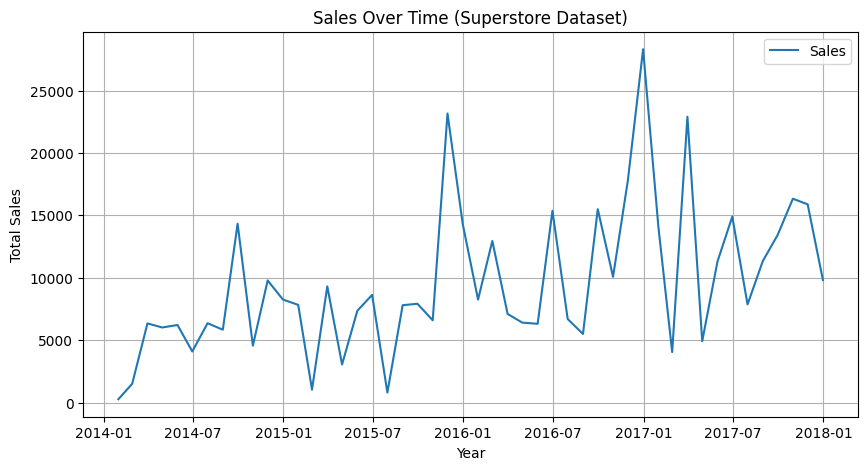

In [12]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales, label='Sales')

plt.title('Sales Over Time (Superstore Dataset)')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend()
plt.grid()

plt.show()

In [13]:
monthly_sales_rolling = monthly_sales.rolling(window=12).mean()

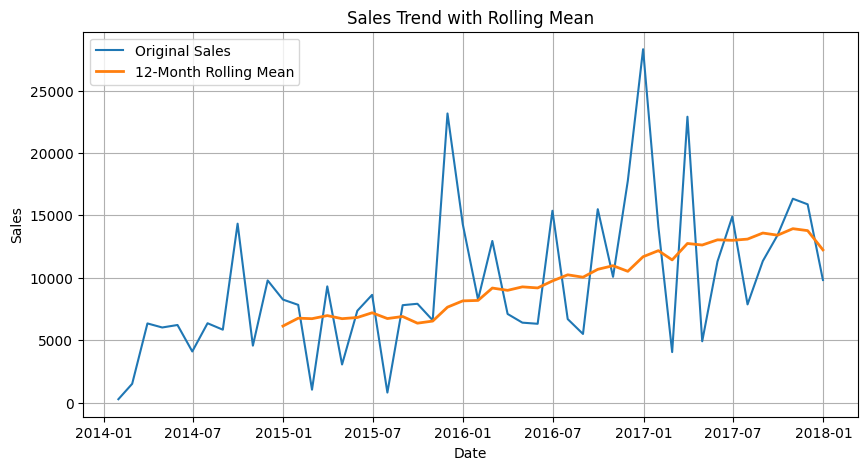

In [14]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Original Sales')
plt.plot(monthly_sales_rolling, label='12-Month Rolling Mean', linewidth=2)

plt.legend()
plt.title("Sales Trend with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()

plt.show()

In [16]:
rolling_std = monthly_sales.rolling(window=12).std()

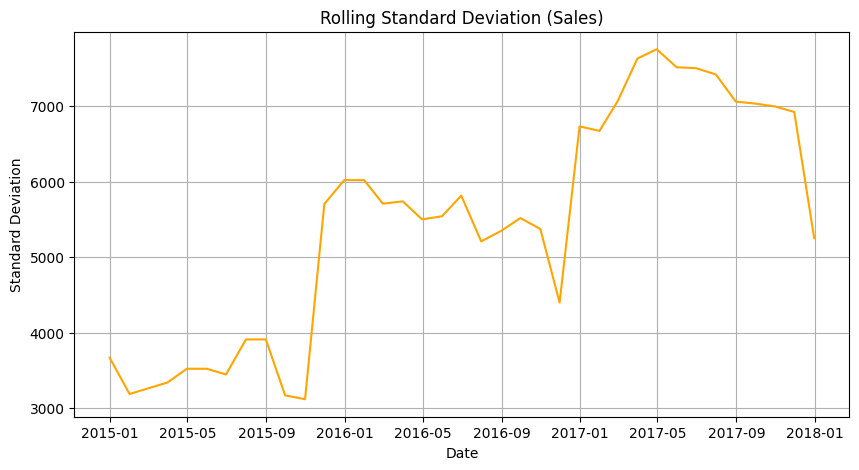

In [17]:
plt.figure(figsize=(10,5))
plt.plot(rolling_std, color='orange')

plt.title("Rolling Standard Deviation (Sales)")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.grid()

plt.show()

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose


In [19]:
decomp = seasonal_decompose(monthly_sales, model='multiplicative', period=12)

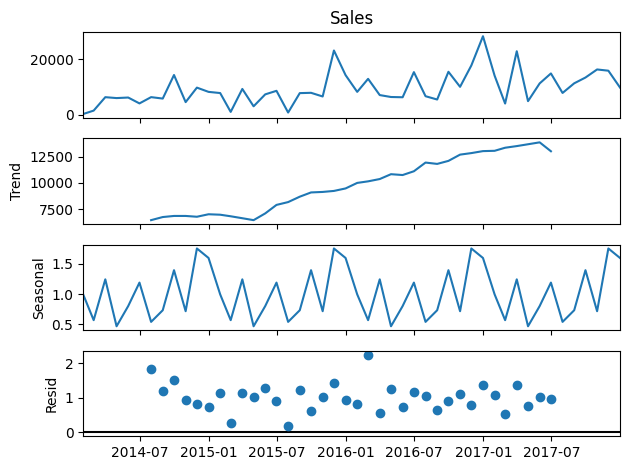

In [20]:
decomp.plot()
plt.show()

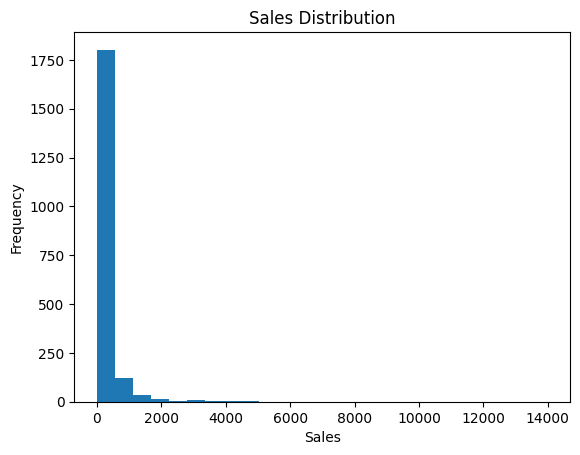

In [25]:
plt.hist(data['Sales'], bins=25)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

📊 Observations on Superstore Sales Time Series Dataset
🔹 1. Overall Growth Trend in Sales

The dataset shows a gradual increase in sales over time, indicating:

Business expansion over the years
Increasing customer demand
Growth in product adoption and market reach
🔹 2. Presence of Seasonality

A repeating seasonal pattern can be observed:

Higher sales during certain months (e.g., festive or year-end periods)
Lower sales during off-season months

👉 This reflects customer purchasing behavior and seasonal demand.

🔹 3. Increasing Seasonal Fluctuations (Multiplicative Behavior)

Over time:

Peaks in sales are getting higher
Even the lower points are increasing

👉 This suggests multiplicative seasonality, where:

Seasonal variation increases with overall sales growth
🔹 4. Non-Stationary Nature of Data

The time series shows:

Increasing mean (trend)
Changing variance over time

👉 Therefore, the data is non-stationary, meaning:

It requires transformation (log, differencing) before forecasting models
🔹 5. Business & Market Influence

The steady rise in sales suggests:

Business growth and expansion
Improved marketing strategies
Increasing customer base
🔹 6. Stable Growth with Minor Fluctuations
No extreme sudden drops or spikes
Sales grow in a relatively smooth pattern

👉 Indicates a stable business environment

🔹 7. Monthly Sales Patterns

From monthly analysis:

Certain months consistently show higher sales
Others show relatively lower performance

👉 Shows clear cyclical demand patterns

🔹 8. Distribution of Sales Data
Sales distribution is right-skewed
Majority of values are lower, with some high-value sales

👉 This indicates:

Presence of large transactions/outliers
Uneven distribution of sales amounts